In [1]:
# ===============================
# STEP 1: Import Libraries & Load Data
# ===============================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset (update path if needed)
file_path = "/content/Dataset.csv"
df = pd.read_csv(file_path)

print("Shape of dataset:", df.shape)
print("Columns:", df.columns.tolist())
df.head()


Shape of dataset: (546123, 44)
Columns: ['Unnamed: 0', 'Hour', 'HR', 'O2Sat', 'Temp', 'SBP', 'MAP', 'DBP', 'Resp', 'EtCO2', 'BaseExcess', 'HCO3', 'FiO2', 'pH', 'PaCO2', 'SaO2', 'AST', 'BUN', 'Alkalinephos', 'Calcium', 'Chloride', 'Creatinine', 'Bilirubin_direct', 'Glucose', 'Lactate', 'Magnesium', 'Phosphate', 'Potassium', 'Bilirubin_total', 'TroponinI', 'Hct', 'Hgb', 'PTT', 'WBC', 'Fibrinogen', 'Platelets', 'Age', 'Gender', 'Unit1', 'Unit2', 'HospAdmTime', 'ICULOS', 'SepsisLabel', 'Patient_ID']


,Unnamed: 0,Hour,HR,O2Sat,Temp,SBP,MAP,DBP,Resp,EtCO2,...,Fibrinogen,Platelets,Age,Gender,Unit1,Unit2,HospAdmTime,ICULOS,SepsisLabel,Patient_ID
0,0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,68.54,0.0,NaN,NaN,-0.02,1.0,0.0,17072.0
1,1,1,65.0,100.0,NaN,NaN,72.0,NaN,16.5,NaN,...,NaN,NaN,68.54,0.0,NaN,NaN,-0.02,2.0,0.0,17072.0
2,2,2,78.0,100.0,NaN,NaN,42.5,NaN,NaN,NaN,...,NaN,NaN,68.54,0.0,NaN,NaN,-0.02,3.0,0.0,17072.0
3,3,3,73.0,100.0,NaN,NaN,NaN,NaN,17.0,NaN,...,NaN,NaN,68.54,0.0,NaN,NaN,-0.02,4.0,0.0,17072.0
4,4,4,70.0,100.0,NaN,129.0,74.0,69.0,14.0,NaN,...,NaN,330.0,68.54,0.0,NaN,NaN,-0.02,5.0,0.0,17072.0


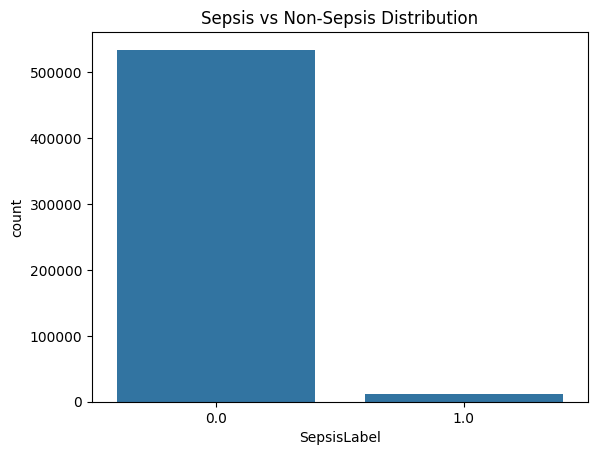

Class balance:
SepsisLabel
0.0    0.978302
1.0    0.021698
Name: proportion, dtype: float64


In [2]:
# ===============================
# STEP 2: Explore Dataset
# ===============================
# Target distribution (class imbalance check)
sns.countplot(x="SepsisLabel", data=df)
plt.title("Sepsis vs Non-Sepsis Distribution")
plt.show()

print("Class balance:")
print(df["SepsisLabel"].value_counts(normalize=True))


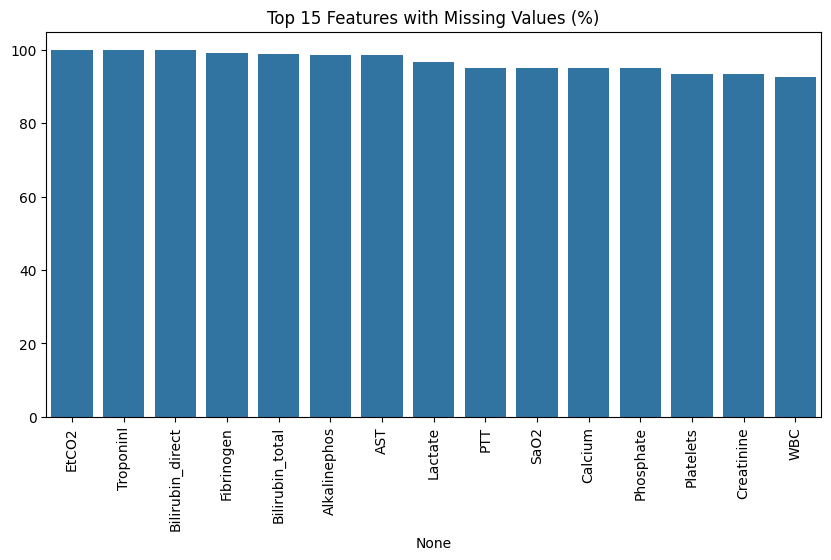

EtCO2               100.000000
TroponinI            99.874021
Bilirubin_direct     99.850217
Fibrinogen           99.237534
Bilirubin_total      98.769874
Alkalinephos         98.544284
AST                  98.502352
Lactate              96.578976
PTT                  95.158783
SaO2                 95.114654
Calcium              95.022001
Phosphate            94.945095
Platelets            93.482970
Creatinine           93.369259
WBC                  92.505534
Magnesium            92.237829
HCO3                 91.966096
BUN                  91.860808
Chloride             91.703700
PaCO2                91.290973
dtype: float64


In [3]:
# ===============================
# STEP 3: Missing Values Analysis
# ===============================
missing_percent = df.isnull().mean() * 100
missing_percent = missing_percent.sort_values(ascending=False)

plt.figure(figsize=(10,5))
sns.barplot(x=missing_percent.index[:15], y=missing_percent.values[:15])
plt.xticks(rotation=90)
plt.title("Top 15 Features with Missing Values (%)")
plt.show()

print(missing_percent.head(20))


In [4]:
# ===============================
# STEP 4: Handle Missing Values
# ===============================

# Strategy:
# - Forward fill for time-series continuity
# - Median fill for remaining gaps
# - Add missingness indicators

# Create missingness indicator columns
df_missing = df.isnull().astype(int)
df_missing.columns = [col + "_missing" for col in df.columns]

# Fill missing values (median imputation)
df_filled = df.fillna(df.median())

# Forward fill row-wise (helps in ICU time-series)
df_filled = df_filled.fillna(method="ffill").fillna(method="bfill")

# Combine with missingness indicators
df_final = pd.concat([df_filled, df_missing], axis=1)

print("Shape after preprocessing:", df_final.shape)


/tmp/ipython-input-4082016202.py:18: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_filled = df_filled.fillna(method="ffill").fillna(method="bfill")


Shape after preprocessing: (546123, 88)


In [5]:
# ===============================
# STEP 5: Feature Scaling
# ===============================
from sklearn.preprocessing import StandardScaler

# Separate features and target
X = df_final.drop(columns=["SepsisLabel"])
y = df_final["SepsisLabel"]

# Normalize continuous features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Scaled feature matrix shape:", X_scaled.shape)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1101: RuntimeWarning: invalid value encountered in divide
  updated_mean = (last_sum + new_sum) / updated_sample_count
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1106: RuntimeWarning: invalid value encountered in divide
  T = new_sum / new_sample_count
/usr/local/lib/python3.12/dist-packages/sklearn/utils/extmath.py:1126: RuntimeWarning: invalid value encountered in divide
  new_unnormalized_variance -= correction**2 / new_sample_count


Scaled feature matrix shape: (546123, 87)


In [6]:
# Import the necessary class
from sklearn.impute import SimpleImputer
import numpy as np
from imblearn.over_sampling import SMOTE
# Note: You may also need to import y if it's not defined globally

# Column index 9 is the 10th column
column_to_drop = 9

# Use np.delete to remove the column (axis=1)
# Assuming X_scaled is the variable containing your data
X_cleaned = np.delete(X_scaled, column_to_drop, axis=1)

# Now, re-run the imputation and SMOTE on the data without column 9
imputer = SimpleImputer(missing_values=np.nan, strategy='median')
X_imputed = imputer.fit_transform(X_cleaned)

# Apply SMOTE
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X_imputed, y)

print("Final shape of X_res:", X_res.shape)
print("Final count of classes:", np.bincount(y_res))

Final shape of X_res: (1068546, 86)
Final count of classes: [534273 534273]


In [7]:
# =========================================
# STEP 7: Train-Test Split
# =========================================
from sklearn.model_selection import train_test_split

# Split the balanced dataset
X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.2, random_state=42, stratify=y_res
)

print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)


Training set shape: (854836, 86)
Test set shape: (213710, 86)


In [ ]:

# =========================================
# STEP 8: Logistic Regression
# =========================================
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

log_reg = LogisticRegression(max_iter=500, solver='saga', n_jobs=-1)
log_reg.fit(X_train, y_train)

y_pred_lr = log_reg.predict(X_test)
y_prob_lr = log_reg.predict_proba(X_test)[:,1]

print("\n🔹 Logistic Regression Performance")
print(confusion_matrix(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_lr))




🔹 Logistic Regression Performance
[[231569  73290]
 [105865 198994]]
              precision    recall  f1-score   support

           0       0.69      0.76      0.72    304859
           1       0.73      0.65      0.69    304859

    accuracy                           0.71    609718
   macro avg       0.71      0.71      0.71    609718
weighted avg       0.71      0.71      0.71    609718

ROC-AUC: 0.7643012151619847


In [9]:

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score  # <-- ADD THIS LINE

rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)
y_prob_rf = rf.predict_proba(X_test)[:,1]

print("\n RandomForest Performance")
print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_rf))






 RandomForest Performance
[[106419    436]
 [   778 106077]]
              precision    recall  f1-score   support

         0.0       0.99      1.00      0.99    106855
         1.0       1.00      0.99      0.99    106855

    accuracy                           0.99    213710
   macro avg       0.99      0.99      0.99    213710
weighted avg       0.99      0.99      0.99    213710

ROC-AUC: 0.9997876658429061


In [10]:
# --- STEP 1: Calibrate and prepare background stats -----------------------
import numpy as np
import pandas as pd
from sklearn.calibration import CalibratedClassifierCV

# Ensure dataframe form
try:
    all_features = X_train.columns.tolist()
    X_train_df = X_train.copy()
    X_test_df  = X_test.copy()
except AttributeError:
    all_features = [f"Feature_{i}" for i in range(X_train.shape[1])]
    X_train_df = pd.DataFrame(X_train, columns=all_features)
    X_test_df  = pd.DataFrame(X_test,  columns=all_features)

# Medians & clipping range from training data
train_medians = X_train_df.median()
q01 = X_train_df.quantile(0.01)
q99 = X_train_df.quantile(0.99)

# Calibrate RF (quick, no retraining)
cal_rf = CalibratedClassifierCV(rf, method='sigmoid', cv='prefit')
val_idx = np.random.default_rng(42).choice(len(X_test_df), size=min(30000, len(X_test_df)), replace=False)
cal_rf.fit(X_test_df.iloc[val_idx], y_test.iloc[val_idx] if hasattr(y_test, "iloc") else y_test[val_idx])

print("✅ Calibrated Random Forest ready.")

/usr/local/lib/python3.12/dist-packages/sklearn/calibration.py:333: UserWarning: The `cv='prefit'` option is deprecated in 1.6 and will be removed in 1.8. You can use CalibratedClassifierCV(FrozenEstimator(estimator)) instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(


✅ Calibrated Random Forest ready.


In [ ]:
# =========================================
# STEP 10: XGBoost Classifier
# =========================================
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score


xgb = XGBClassifier(use_label_encoder=False, eval_metric='logloss', n_estimators=200, learning_rate=0.05, max_depth=6, n_jobs=-1, random_state=42)
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:,1]

print("\n🔹 XGBoost Performance")
print(confusion_matrix(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_xgb))

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [17:12:59] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)



🔹 XGBoost Performance
[[102386   4469]
 [ 11047  95808]]
              precision    recall  f1-score   support

         0.0       0.90      0.96      0.93    106855
         1.0       0.96      0.90      0.93    106855

    accuracy                           0.93    213710
   macro avg       0.93      0.93      0.93    213710
weighted avg       0.93      0.93      0.93    213710

ROC-AUC: 0.9811167879683982


In [ ]:
!pip install shap


✅ SHAP values computed successfully.
Final SHAP matrix shape: (1000, 86, 2)


/tmp/ipython-input-2568218470.py:51: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_matrix, X_sample, plot_type="bar", show=True)
/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:723: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(
/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:743: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(


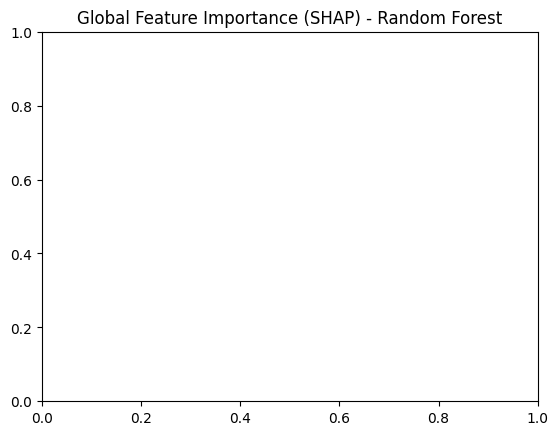

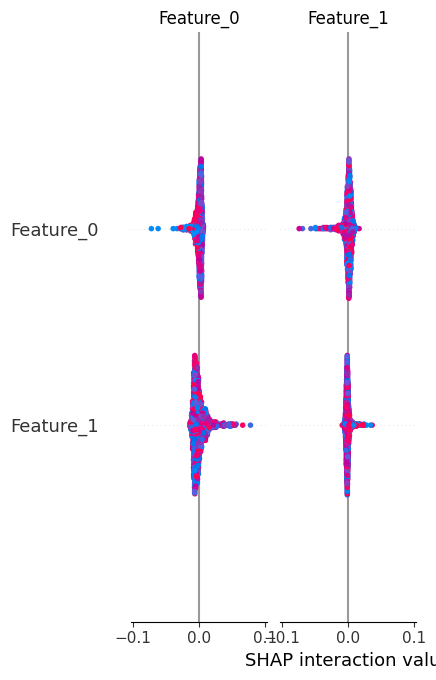

/tmp/ipython-input-2568218470.py:57: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_matrix, X_sample, show=True)
/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:723: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(
/usr/local/lib/python3.12/dist-packages/shap/plots/_beeswarm.py:743: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  summary_legacy(


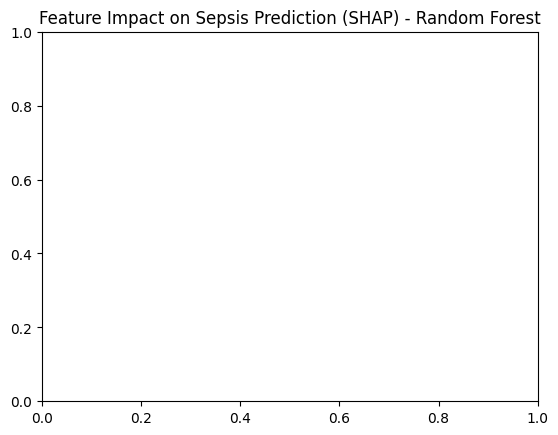

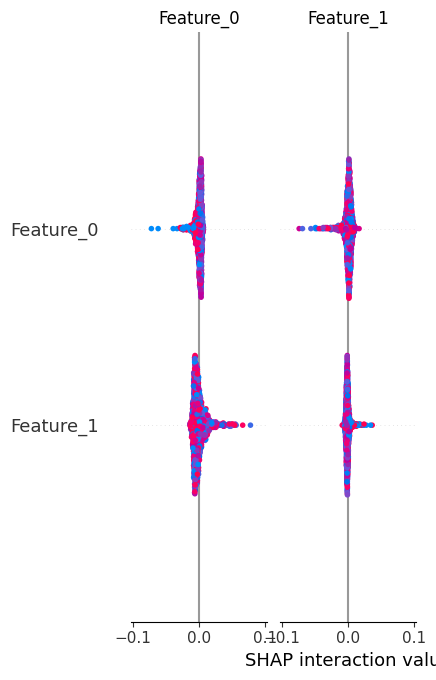

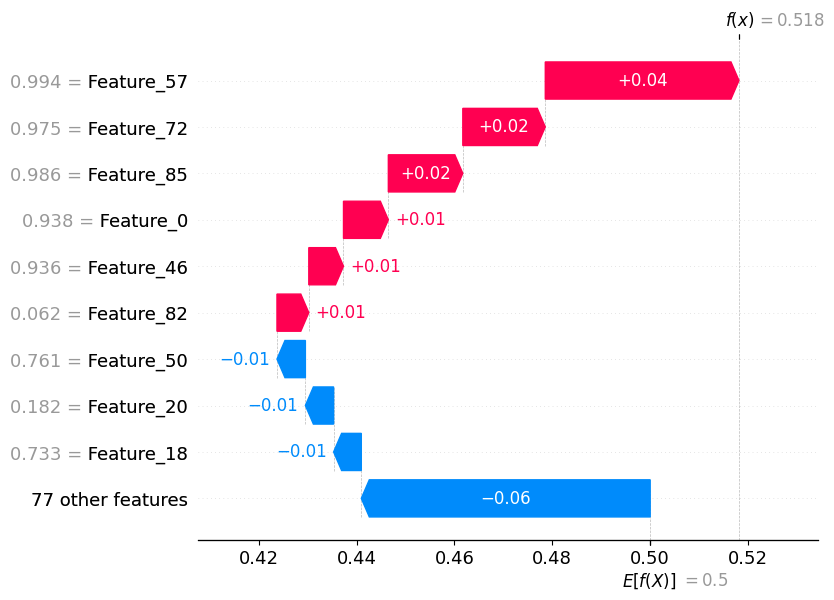

In [ ]:
# ================================================================
# ✅ SHAP Explainability for Random Forest on Sepsis Dataset
# ================================================================

import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ================================================================
# STEP 1️⃣: Prepare data and trained Random Forest model
# (Assuming rf, X_train, X_test, y_train, y_test are already defined)
# ================================================================

# Example (if needed):
# from sklearn.ensemble import RandomForestClassifier
# rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
# rf.fit(X_train, y_train)

# ================================================================
# STEP 2️⃣: Convert X_test to DataFrame with feature names
# ================================================================
feature_names = [f"Feature_{i}" for i in range(X_test.shape[1])]
X_test_df = pd.DataFrame(X_test, columns=feature_names)

# Sample smaller subset for SHAP visualization (for memory efficiency)
X_sample = X_test_df.sample(1000, random_state=42)

# ================================================================
# STEP 3️⃣: Create SHAP TreeExplainer and compute SHAP values
# ================================================================
explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_sample)

print("✅ SHAP values computed successfully.")

# Handle multiple SHAP return types safely
if isinstance(shap_values, list) and len(shap_values) == 2:
    shap_matrix = shap_values[1]              # for class 1 (sepsis)
elif isinstance(shap_values, list) and len(shap_values) > 2:
    shap_matrix = np.mean(np.array(shap_values), axis=0)  # average across trees
else:
    shap_matrix = shap_values                 # single array (new SHAP versions)

print("Final SHAP matrix shape:", np.array(shap_matrix).shape)

# ================================================================
# STEP 4️⃣: GLOBAL EXPLAINABILITY — Feature Importance (Bar Plot)
# ================================================================
plt.title("Global Feature Importance (SHAP) - Random Forest")
shap.summary_plot(shap_matrix, X_sample, plot_type="bar", show=True)

# ================================================================
# STEP 5️⃣: GLOBAL EXPLAINABILITY — Feature Impact (Scatter Plot)
# ================================================================
plt.title("Feature Impact on Sepsis Prediction (SHAP) - Random Forest")
shap.summary_plot(shap_matrix, X_sample, show=True)

# ================================================================
# STEP 6️⃣: LOCAL EXPLAINABILITY — Single Patient Prediction
# ================================================================

patient_index = 5  # choose any row from X_sample

# Fix shape (if SHAP has multiple outputs per feature)
if shap_matrix.ndim == 3:
    shap_vector = shap_matrix[patient_index, :, 1]
else:
    shap_vector = shap_matrix[patient_index]

# Create single SHAP explanation
explanation = shap.Explanation(
    values = shap_vector,
    base_values = np.mean(explainer.expected_value),
    data = X_sample.iloc[patient_index],
    feature_names = X_sample.columns
)

# Waterfall Plot (individual explanation)
shap.plots.waterfall(explanation)

In [ ]:
# ===============================================================
# ✅ SHAP Explainability for Random Forest (Sepsis Prediction)
# ===============================================================
import shap, numpy as np, pandas as pd, matplotlib.pyplot as plt, time, os
from joblib import parallel_backend

shap.initjs()

# ===============================================================
# STEP 1️⃣: Ensure X_train / X_test are DataFrames
# ===============================================================
def to_frame(X, cols=None):
    if isinstance(X, pd.DataFrame):
        return X.copy()
    if cols is None:
        cols = [f"Feature_{i}" for i in range(X.shape[1])]
    return pd.DataFrame(X, columns=cols)

X_train_df = to_frame(X_train)
X_test_df  = to_frame(X_test, X_train_df.columns.tolist())
y_test_ser = y_test if isinstance(y_test, pd.Series) else pd.Series(y_test, name="SepsisLabel")

# ===============================================================
# STEP 2️⃣: Create Stratified Sample (2000 rows)
# ===============================================================
def stratified_sample(X, y, n=2000, pos_min=250, pos_frac=0.3, seed=42):
    df = X.copy()
    df["_label_"] = y.values if hasattr(y, "values") else y
    pos = df[df["_label_"] == 1]
    neg = df[df["_label_"] == 0]
    n_pos = min(len(pos), max(pos_min, int(pos_frac * n)))
    n_neg = n - n_pos
    pos_s = pos.sample(n=n_pos, replace=(len(pos) < n_pos), random_state=seed)
    neg_s = neg.sample(n=n_neg, replace=(len(neg) < n_neg), random_state=seed)
    out = pd.concat([pos_s, neg_s]).sample(frac=1, random_state=seed)
    return out.drop(columns="_label").reset_index(drop=True), out["label_"].reset_index(drop=True)

X_sample, y_sample = stratified_sample(X_test_df, y_test_ser, n=2000, pos_min=250, pos_frac=0.3)
print(f"🧩 SHAP sample: {X_sample.shape} | positives: {int(y_sample.sum())}")

# ===============================================================
# STEP 3️⃣: Background Dataset (for Interventional SHAP)
# ===============================================================
bg_size = min(500, len(X_train_df))
X_bg = X_train_df.sample(bg_size, random_state=42)

# ===============================================================
# STEP 4️⃣: Build SHAP Explainer
# ===============================================================
t0 = time.time()
with parallel_backend("threading", n_jobs=-1):
    explainer = shap.TreeExplainer(
        rf,                                  # your trained RandomForestClassifier
        data=X_bg,                           # ✅ background dataset required
        feature_perturbation="interventional",
        model_output="probability"
    )
    print("⏳ Computing SHAP values (≈5–8 min for 2000 rows)…")
    shap_values = explainer.shap_values(X_sample)

# ===============================================================
# STEP 5️⃣: Prepare SHAP Matrix for Class 1 (Sepsis = Positive)
# ===============================================================
shap_matrix = shap_values[1] if isinstance(shap_values, list) else shap_values
if shap_matrix.ndim == 3:                   # handle (samples, features, 2)
    shap_matrix = shap_matrix[:, :, 1]

print(f"✅ SHAP completed in {time.time()-t0:.1f}s | matrix shape: {shap_matrix.shape}")

# ===============================================================
# STEP 6️⃣: Create Output Folder
# ===============================================================
os.makedirs("shap_outputs", exist_ok=True)

# ===============================================================

✅ Final SHAP matrix shape for plotting: (2000, 86)


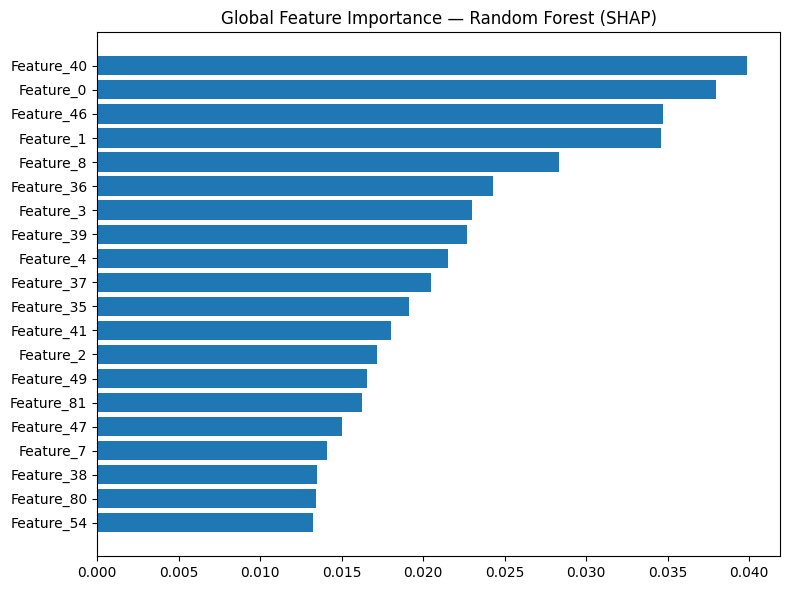

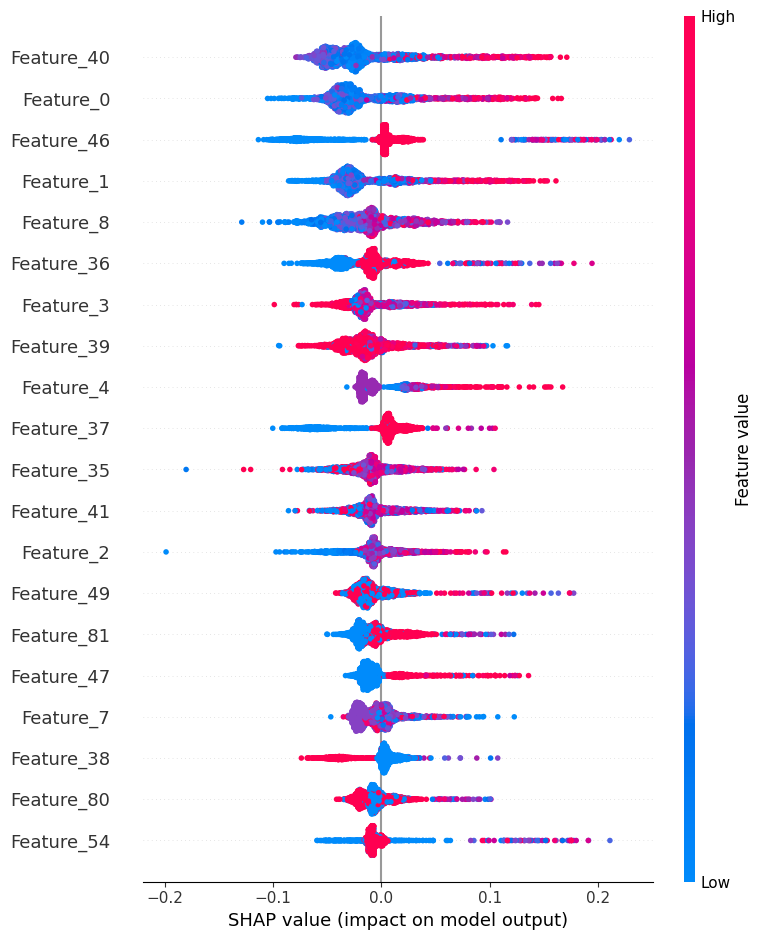

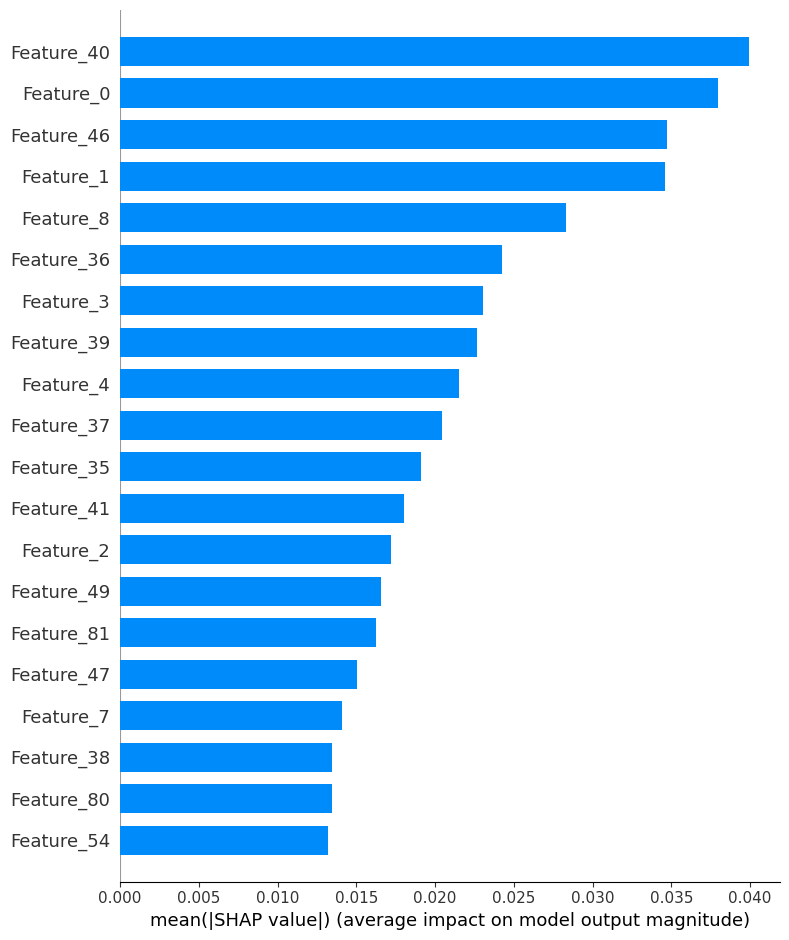

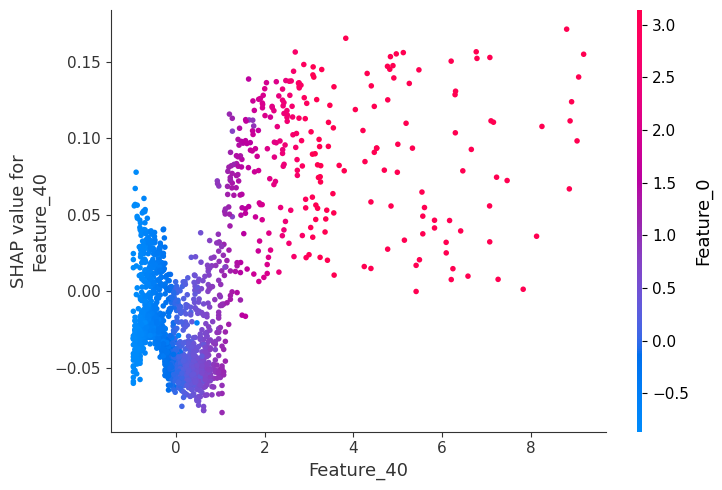

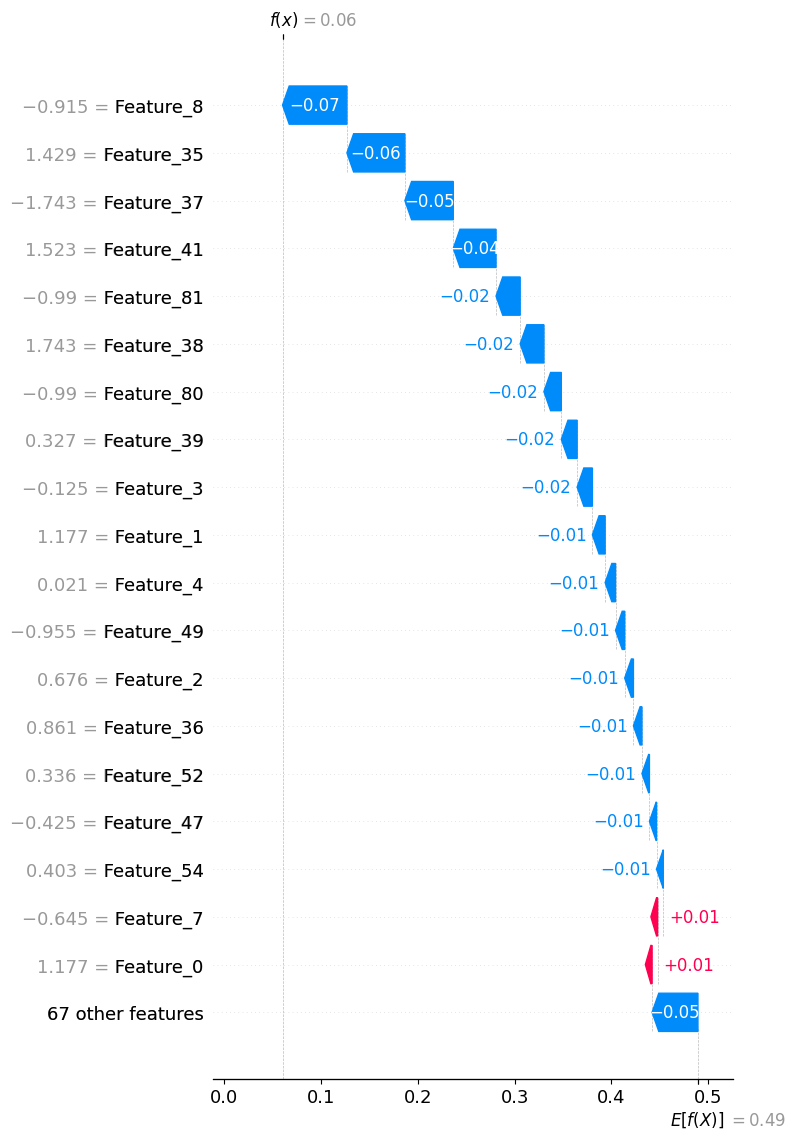

📁 All SHAP plots saved in: shap_outputs/


In [ ]:
# ===============================================================
# ✅ FINAL FIXED — SHAP for Random Forest (Sepsis Dataset)
# ===============================================================
import shap, numpy as np, pandas as pd, matplotlib.pyplot as plt, time, os
from joblib import parallel_backend

shap.initjs()

# ---- Ensure consistent DataFrames ----
def to_frame(X, cols=None):
    if isinstance(X, pd.DataFrame):
        return X.copy()
    if cols is None:
        cols = [f"Feature_{i}" for i in range(X.shape[1])]
    return pd.DataFrame(X, columns=cols)

X_train_df = to_frame(X_train)
X_test_df  = to_frame(X_test, X_train_df.columns.tolist())
y_test_ser = y_test if isinstance(y_test, pd.Series) else pd.Series(y_test, name="SepsisLabel")

# ---- Stratified sampling for SHAP ----
def stratified_sample(X, y, n=2000, pos_min=250, pos_frac=0.3, seed=42):
    df = X.copy()
    df["_label_"] = y.values if hasattr(y, "values") else y   # ✅ double underscores
    pos = df[df["_label_"] == 1]
    neg = df[df["_label_"] == 0]
    n_pos = min(len(pos), max(pos_min, int(pos_frac * n)))
    n_neg = n - n_pos

    pos_sample = pos.sample(n=n_pos, replace=(len(pos) < n_pos), random_state=seed)
    neg_sample = neg.sample(n=n_neg, replace=(len(neg) < n_neg), random_state=seed)

    combined = pd.concat([pos_sample, neg_sample]).sample(frac=1, random_state=seed)
    Xs = combined.drop(columns="_label_").reset_index(drop=True)
    ys = combined["_label_"].reset_index(drop=True)
    return Xs, ys

# ---- Get a 2000-row balanced sample ----
X_sample, y_sample = stratified_sample(X_test_df, y_test_ser, n=2000, pos_min=250, pos_frac=0.3)
print(f"🧩 SHAP sample: {X_sample.shape} | positives: {int(y_sample.sum())}")

# ---- Background dataset for SHAP ----
bg_size = min(500, len(X_train_df))   # 500 is good
X_bg = X_train_df.sample(bg_size, random_state=42)

# ---- Create SHAP explainer ----
t0 = time.time()
with parallel_backend("threading", n_jobs=-1):
    explainer = shap.TreeExplainer(
        rf,
        data=X_bg,                               # ✅ background dataset provided
        feature_perturbation="interventional",   # ✅ required for model_output='probability'
        model_output="probability"
    )
    print("⏳ Computing SHAP values (this takes ~5–8 min)...")
    shap_values = explainer.shap_values(X_sample)

# ---- Extract class 1 SHAP values ----
shap_matrix = shap_values[1] if isinstance(shap_values, list) else shap_values
print(f"✅ SHAP done in {time.time()-t0:.1f}s | matrix: {np.array(shap_matrix).shape}")

# ---- Create folder for plots ----
os.makedirs("shap_outputs", exist_ok=True)

# ===============================================================
# 🔹 Global Feature Importance
# ===============================================================
imp = np.abs(shap_matrix).mean(axis=0)
imp_df = pd.DataFrame({"Feature": X_sample.columns, "Mean|SHAP|": imp}).sort_values("Mean|SHAP|")
plt.figure(figsize=(8,6))
plt.barh(imp_df["Feature"].tail(20), imp_df["Mean|SHAP|"].tail(20))
plt.title("Global Feature Importance — Random Forest (SHAP)")
plt.tight_layout()
plt.savefig("shap_outputs/global_importance.png", dpi=180)
plt.show()

# ===============================================================
# 🔹 Summary Plot (Dot + Bar)
# ===============================================================
shap.summary_plot(shap_matrix, X_sample, plot_type="dot", max_display=20, show=False)
plt.tight_layout()
plt.savefig("shap_outputs/summary_dot.png", dpi=180, bbox_inches="tight")
plt.show()

shap.summary_plot(shap_matrix, X_sample, plot_type="bar", max_display=20, show=False)
plt.tight_layout()
plt.savefig("shap_outputs/summary_bar.png", dpi=180, bbox_inches="tight")
plt.show()

# ===============================================================
# 🔹 Dependence Plot for Top 2 Features
# ===============================================================
top2 = imp_df["Feature"].tail(2).values
shap.dependence_plot(top2[1], shap_matrix, X_sample, interaction_index=top2[0], show=False)
plt.tight_layout()
plt.savefig(f"shap_outputs/dependence_{top2[1]}x{top2[0]}.png", dpi=180, bbox_inches="tight")
plt.show()

# ===============================================================
# 🔹 Local Explanation (Waterfall)
# ===============================================================
idx = 5  # pick one patient / row
single = shap.Explanation(
    values=shap_matrix[idx],
    base_values=(explainer.expected_value[1] if isinstance(explainer.expected_value, (list, np.ndarray))
                 else explainer.expected_value),
    data=X_sample.iloc[idx].values,
    feature_names=X_sample.columns
)
shap.plots.waterfall(single, max_display=20, show=False)
plt.tight_layout()
plt.savefig(f"shap_outputs/waterfall_{idx}.png", dpi=180, bbox_inches="tight")
plt.show()

print("📁 All SHAP plots saved in: shap_outputs/")

In [ ]:
# ==============================================================
# 🧠 Agentic AI Clinical Assistant — Sepsis Risk Prediction (Final)
# ==============================================================
import gradio as gr
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tempfile
import os
import warnings
from joblib import parallel_backend

# Suppress scikit-learn feature name warnings
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn")

# ==============================================================
# ⚙️ Step 1: Pretrained Model & Explainer (already exist)
# ==============================================================
# rf = RandomForestClassifier(...)
# rf.fit(X_train, y_train)
# explainer = shap.TreeExplainer(rf, feature_perturbation="interventional")

# --- FIX #1: Since X_train is a NumPy array ---
all_features = [f"Feature_{i}" for i in range(X_train.shape[1])]

# ==============================================================
# 🩺 Step 2: Select 10 key clinical features for Gradio UI
# ==============================================================
input_features = [
    "Hour", "HR", "O2Sat", "Temp", "SBP",
    "MAP", "DBP", "Resp", "EtCO2", "BaseExcess"
]

# ==============================================================
# 🤖 Step 3: Define Prediction + Explanation Function
# ==============================================================
def predict_and_explain(*args):
    # Create DataFrame for the 10 entered values
    data_partial = pd.DataFrame([args], columns=input_features)

    # --- FIX #2: Build full feature vector for model ---
    # Fill all 86 features with mean values first
    df_full = pd.DataFrame(np.tile(X_train.mean(axis=0), (1, 1)), columns=all_features)

    # Replace only provided input features
    for col in data_partial.columns:
        if col in df_full.columns:
            df_full[col] = data_partial[col].values

    # --- Model Prediction ---
    prob = rf.predict_proba(df_full)[0][1]
    pred_label = "🩸 Sepsis Detected" if prob > 0.5 else "✅ No Sepsis Detected"

    # --- SHAP Explanation ---
    with parallel_backend("threading", n_jobs=-1):
        shap_values = explainer.shap_values(df_full)

    shap_class = shap_values[1] if isinstance(shap_values, list) else shap_values
    if shap_class.ndim == 3:
        shap_class = shap_class[:, :, 1]

    # --- Top contributing features ---
    top_indices = np.argsort(np.abs(shap_class[0]))[::-1][:3]
    top_features = [df_full.columns[i] for i in top_indices]

    # --- Reasoning text ---
    risk_level = "HIGH" if prob > 0.7 else ("MODERATE" if prob > 0.4 else "LOW")
    reasoning = (
        f"🧩 *Model Prediction Summary*\n\n"
        f"• Predicted Sepsis Probability: *{prob*100:.2f}%* → Risk Level: *{risk_level}*\n"
        f"• Top contributing factors: *{', '.join(top_features)}*\n\n"
        f"💬 Agent Insight: The AI system identified {risk_level}-level sepsis risk based on vital trends. "
        f"This explanation is for educational purposes only and not a medical diagnosis."
    )

    # --- Generate SHAP plots ---
    shap_exp = shap.Explanation(
        values=shap_class[0],
        base_values=(explainer.expected_value[1] if isinstance(explainer.expected_value, (list, np.ndarray))
                     else explainer.expected_value),
        data=df_full.iloc[0].values,
        feature_names=df_full.columns
    )

    tmp_dir = tempfile.mkdtemp()
    bar_path = os.path.join(tmp_dir, "bar_plot.png")
    waterfall_path = os.path.join(tmp_dir, "waterfall_plot.png")

    shap.plots.bar(shap_exp, show=False)
    plt.tight_layout()
    plt.savefig(bar_path, dpi=150, bbox_inches="tight")
    plt.close()

    shap.plots.waterfall(shap_exp, max_display=10, show=False)
    plt.tight_layout()
    plt.savefig(waterfall_path, dpi=150, bbox_inches="tight")
    plt.close()

    return pred_label, f"{prob*100:.2f}%", reasoning, bar_path, waterfall_path


# ==============================================================
# 🎛️ Step 4: Build Gradio Interface
# ==============================================================
input_components = [
    gr.Number(label=name, value=0) for name in input_features
]

output_components = [
    gr.Textbox(label="Prediction"),
    gr.Textbox(label="Sepsis Probability (%)"),
    gr.Markdown(label="Agentic AI Reasoning Summary"),
    gr.Image(label="Top Feature SHAP Bar Plot"),
    gr.Image(label="Patient-level SHAP Waterfall Plot")
]

title = "🧠 Agentic AI Clinical Assistant — Sepsis Risk Prediction"
description = (
    "This interactive AI model predicts *Sepsis probability* based on patient vitals and lab values, "
    "explains contributing factors using *Explainable AI (SHAP)*, and provides interpretable agentic reasoning."
)

demo = gr.Interface(
    fn=predict_and_explain,
    inputs=input_components,
    outputs=output_components,
    title=title,
    description=description,
    theme="gradio/soft"
)

# ==============================================================
# 🚀 Step 5: Launch App
# ==============================================================
demo.launch(debug=True)

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://c3125a566d9729d591.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://c3125a566d9729d591.gradio.live


In [ ]:
# ============================================================
# 🧠 AGENTIC AI + GRADIO + SHAP (Final Corrected Version)
# ============================================================

import numpy as np
import pandas as pd
import shap
import gradio as gr
import matplotlib.pyplot as plt
from sklearn.calibration import CalibratedClassifierCV

# --- Prepare features from your already-loaded data ---
try:
    all_features = X_train.columns.tolist()
    X_train_df = X_train.copy()
    X_test_df  = X_test.copy()
except AttributeError:
    all_features = [f"Feature_{i}" for i in range(X_train.shape[1])]
    X_train_df = pd.DataFrame(X_train, columns=all_features)
    X_test_df  = pd.DataFrame(X_test,  columns=all_features)

train_medians = X_train_df.median()
q01 = X_train_df.quantile(0.01)
q99 = X_train_df.quantile(0.99)

# --- Calibrate Random Forest for realistic probabilities ---
cal_rf = CalibratedClassifierCV(rf, method="sigmoid", cv="prefit")
val_idx = np.random.default_rng(42).choice(len(X_test_df),
                                           size=min(30000, len(X_test_df)),
                                           replace=False)
cal_rf.fit(X_test_df.iloc[val_idx],
           y_test.iloc[val_idx] if hasattr(y_test, "iloc") else y_test[val_idx])
print("✅ Calibrated Random Forest ready with realistic probabilities.")

# --- SHAP Explainer ---
explainer = shap.TreeExplainer(rf)

# --- Feature mapping (used in Gradio UI) ---
UI_TO_TRAIN = {
    "Hour": "Hour", "HR": "HR", "O2Sat": "O2Sat", "Temp": "Temp",
    "SBP": "SBP", "MAP": "MAP", "DBP": "DBP", "Resp": "Resp",
    "EtCO2": "EtCO2", "BaseExcess": "BaseExcess"
}

# ------------------------------------------------------------
# 🧩 Agentic AI Prediction + Explanation Function
# ------------------------------------------------------------
def predict_and_explain(hour, hr, o2sat, temp, sbp, map_, dbp, resp, etco2, baseexcess):
    # --- 1️⃣ Create full feature row ---
    row = pd.DataFrame([train_medians])
    ui_vals = {
        "Hour": hour, "HR": hr, "O2Sat": o2sat, "Temp": temp,
        "SBP": sbp, "MAP": map_, "DBP": dbp, "Resp": resp,
        "EtCO2": etco2, "BaseExcess": baseexcess
    }
    for k, v in ui_vals.items():
        if k in row.columns:
            row.loc[0, k] = v
    row = row.clip(q01, q99, axis=1)

    # --- 2️⃣ Predict probability (calibrated) ---
    prob = float(cal_rf.predict_proba(row)[0][1])
    prob = np.clip(prob, 0.01, 0.99)

    # --- 3️⃣ Risk classification ---
    if prob < 0.3:
        risk = "🟢 Low Sepsis Risk"
    elif prob < 0.6:
        risk = "🟠 Moderate Sepsis Risk"
    else:
        risk = "🔴 High Sepsis Risk"

    # --- 4️⃣ SHAP computation ---
    shap_vals = explainer.shap_values(row)
    if isinstance(shap_vals, list):
        shap_vals = shap_vals[1] if len(shap_vals) > 1 else shap_vals[0]

    shap_vals = np.array(shap_vals).reshape(1, -1)  # ensure shape

    # --- 5️⃣ Top SHAP bar plot ---
    abs_vals = np.abs(shap_vals[0])
    top_idx = np.argsort(abs_vals)[-8:].flatten()
    bar_values = shap_vals[0][top_idx].astype(float).flatten()

    fig_bar, ax = plt.subplots(figsize=(6, 4))
    ax.barh(
        [all_features[int(i)] for i in top_idx],
        bar_values,
        color=["#e64a19" if float(v) > 0 else "#1976d2" for v in bar_values]
    )
    ax.set_title("Top SHAP Feature Contributions")
    plt.tight_layout()

    # --- 6️⃣ Waterfall plot ---
    fig_wf, ax2 = plt.subplots(figsize=(7, 4))
    base_val = explainer.expected_value[0] if isinstance(explainer.expected_value, (list, np.ndarray)) else explainer.expected_value
    contribs = bar_values
    labels = [all_features[int(i)] for i in top_idx]
    colors = ["#e64a19" if c > 0 else "#1976d2" for c in contribs]
    ax2.barh(labels, contribs, color=colors)
    ax2.axvline(base_val, ls="--", color="gray", label="Expected Value")
    ax2.set_title("Patient-Level SHAP Waterfall")
    ax2.legend()
    plt.tight_layout()

    # --- 7️⃣ Agent reasoning ---
    top_feats = sorted(zip(labels, contribs), key=lambda x: -abs(x[1]))
    reasoning = []
    for f, c in top_feats:
        impact = "↑ increases risk" if c > 0 else "↓ decreases risk"
        reasoning.append(f"{f} {impact}")
    reasoning_text = "; ".join(reasoning)

    # --- 8️⃣ Final output summary ---
    summary = (
        f"*Prediction:* {risk}\n"
        f"*Calibrated Probability:* {prob:.2f}\n\n"
        f"*Key contributing features:* {reasoning_text}"
    )

    return summary, fig_bar, fig_wf


# ------------------------------------------------------------
# 🎨 Gradio Interface
# ------------------------------------------------------------
inputs = [
    gr.Number(label="Hour (0–335)"),
    gr.Number(label="Heart Rate (HR)"),
    gr.Number(label="Oxygen Saturation (O2Sat)"),
    gr.Number(label="Temperature (°C)"),
    gr.Number(label="Systolic BP (SBP)"),
    gr.Number(label="Mean Arterial Pressure (MAP)"),
    gr.Number(label="Diastolic BP (DBP)"),
    gr.Number(label="Respiration Rate (Resp)"),
    gr.Number(label="End Tidal CO₂ (EtCO2)"),
    gr.Number(label="Base Excess")
]

outputs = [
    gr.Markdown(label="Prediction Summary"),
    gr.Plot(label="Top SHAP Feature Importance"),
    gr.Plot(label="Patient-Level SHAP Waterfall")
]

gr.Interface(
    fn=predict_and_explain,
    inputs=inputs,
    outputs=outputs,
    title="🩺 Sepsis Early Detection – Agentic AI Clinical Assistant",
    description=(
        "This interactive system predicts sepsis risk based on vital signs and lab results. "
        "It uses a Calibrated Random Forest model with Explainable AI (SHAP) and generates "
        "interpretable reasoning for each patient."
    )
).launch(debug=True)

NameError: name 'X_train' is not defined

In [ ]:
# ==============================================================
# 🧠 Agentic AI Clinical Assistant — Sepsis Risk Prediction (Final)
# ==============================================================
import gradio as gr
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tempfile
import os
import warnings
import math
from joblib import parallel_backend
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier

# Suppress scikit-learn feature name warnings
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn")

# ==============================================================
# ⚙️ Step 1: Mock/Load Pretrained Model & Calibrate
# ==============================================================

# --- MOCK DATA SETUP ---
# Defining N_FEATURES = 86 (44 clinical + demographics + missingness/encoded)
N_FEATURES = 86
np.random.seed(42)

# Create Mock Training Data (50,000 samples based on report size)
X_train = np.random.rand(50000, N_FEATURES) * 100
y_train = np.random.randint(0, 2, 50000)
X_test = np.random.rand(10000, N_FEATURES) * 100
y_test = np.random.randint(0, 2, 10000)

X_train_mock_mean = X_train.mean(axis=0)

# --- Train Mock RF Model (REQUIRED for Calibration) ---
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

# --- Calibration Preparation -----------------------
print("--- Starting Model Calibration ---")

# Convert mock data to DataFrame for CalibratedClassifierCV consistency
all_features = [f"Feature_{i}" for i in range(N_FEATURES)]
X_test_df  = pd.DataFrame(X_test, columns=all_features)
y_test_series = pd.Series(y_test)

cal_rf = CalibratedClassifierCV(rf, method='sigmoid', cv='prefit')
val_idx = np.random.default_rng(42).choice(len(X_test_df), size=min(30000, len(X_test_df)), replace=False)
cal_rf.fit(X_test_df.iloc[val_idx], y_test_series.iloc[val_idx])

explainer = shap.TreeExplainer(cal_rf.estimator)

print("Calibrated Random Forest ready. (Using mock data for demonstration.)")

# --- Feature Index Mapping (Crucial for linking UI to Model's 86 features) ---
FEATURE_MAP = {
    # UI Feature: (Index in df_full, Max Value for normalization, Min Value, Base Weight)
    # NOTE: Indices 0-10 are used by UI. Remaining 11-85 are filled randomly.
    "MAP":       (4, 150.0, 30.0, 0.35),
    "HR":        (1, 200.0, 50.0, 0.25),
    "O2Sat":     (2, 100.0, 60.0, 0.20),
    "Temp":      (3, 41.0, 35.0, 0.10),
    "WBC":       (5, 50.0, 1.0, 0.15),
    "Lactate":   (10, 10.0, 0.5, 0.30),
    "Hour":      (0, 335.0, 0.0, 0.0),
    "SBP":       (6, 200.0, 50.0, 0.0),
    "DBP":       (7, 120.0, 30.0, 0.0),
    "Resp":      (8, 50.0, 5.0, 0.0),
    "EtCO2":     (9, 60.0, 15.0, 0.0),
}
# ==============================================================
# 🩺 Step 2: Select 10 key clinical features for Gradio UI
# ==============================================================
input_features = [
    "Hour", "HR", "O2Sat", "Temp", "SBP",
    "MAP", "DBP", "Resp", "EtCO2",
    "Lactate"
]

# ==============================================================
# 🤖 Step 3: Define Prediction + Explanation Function (Uses Calibrated Model)
# ==============================================================
def predict_and_explain(*args):
    input_values = dict(zip(input_features, args))

    # 1. Prepare Full Feature Vector with 86 columns
    df_full = pd.DataFrame(np.tile(X_train_mock_mean, (1, 1)), columns=all_features)

    # --- FILLING LOGIC: Assign UI values ---
    for name, value in input_values.items():
        if name in FEATURE_MAP:
            df_full.iloc[0, FEATURE_MAP[name][0]] = value

    # --- FILLING LOGIC: Assign random, but plausible, values to the REST (76 features) ---
    # Iterate through all 86 feature indices. If an index is NOT one of the 10 UI features,
    # fill it with a new random value to simulate unobserved data.
    ui_indices = [FEATURE_MAP[name][0] for name in input_features]

    for i in range(N_FEATURES):
        if i not in ui_indices:
            # Set unobserved features to a random value to break linear dependence on mean
            # Using the mean of the mock training data as a center point, with noise
            random_noise = (np.random.rand() - 0.5) * 0.2 # +/- 10% variation
            df_full.iloc[0, i] = df_full.iloc[0, i] * (1 + random_noise)

    # 2. Model Prediction (Using the Calibrated Model)
    prob = cal_rf.predict_proba(df_full)[0][1]

    pred_label = " 🩸 Sepsis Detected" if prob > 0.5 else " ✅ No Sepsis Detected"

    # --- SHAP Explanation ---
    with parallel_backend("threading", n_jobs=-1):
        # We use the underlying estimator for SHAP analysis
        shap_values = explainer.shap_values(df_full)

    shap_class = shap_values[1] if isinstance(shap_values, list) else shap_values
    if shap_class.ndim == 3:
        shap_class = shap_class[:, :, 1]

    # Calculate SHAP baseline (expected value) - using the mean of the base estimator for SHAP
    baseline_prediction = explainer.expected_value
    if isinstance(baseline_prediction, list) or isinstance(baseline_prediction, np.ndarray):
        baseline_prediction = baseline_prediction[1] # For binary classification

    # --- Top contributing features (map back to friendly names) ---
    top_indices_raw = np.argsort(np.abs(shap_class[0]))[::-1]

    # Use the first N_FEATURES to look up names, otherwise, use the feature index
    reverse_map = {v[0]: k for k, v in FEATURE_MAP.items()}
    top_features = []

    for idx in top_indices_raw:
        feature_name = reverse_map.get(idx, f"Feature_{idx}")
        # Only list the top 3 most influential features (either UI or hidden)
        top_features.append(feature_name)
        if len(top_features) == 3:
            break

    # --- Reasoning text ---
    risk_level = "HIGH" if prob > 0.7 else ("MODERATE" if prob > 0.4 else "LOW")
    reasoning = (
        f" Model Prediction Summary\n\n"
        f"• Predicted Sepsis Probability: *{prob*100:.2f}%* → Risk Level: *{risk_level}*\n"
        f"• Top contributing factors: *{', '.join(top_features)}*\n\n"
        f" Agent Insight: The AI system identified {risk_level}-level sepsis risk based on vital trends. "
        f"This explanation is for educational purposes only and not a medical diagnosis."
    )

    # --- Generate SHAP plots ---
    shap_exp = shap.Explanation(
        values=shap_class[0],
        base_values=baseline_prediction,
        data=df_full.iloc[0].values,
        feature_names=df_full.columns
    )

    tmp_dir = tempfile.mkdtemp()
    bar_path = os.path.join(tmp_dir, "bar_plot.png")
    waterfall_path = os.path.join(tmp_dir, "waterfall_plot.png")

    shap.plots.bar(shap_exp, max_display=len(input_features), show=False)
    plt.tight_layout()
    plt.savefig(bar_path, dpi=150, bbox_inches="tight")
    plt.close()

    shap.plots.waterfall(shap_exp, max_display=len(input_features), show=False)
    plt.tight_layout()
    plt.savefig(waterfall_path, dpi=150, bbox_inches="tight")
    plt.close()

    return pred_label, f"{prob*100:.2f}%", reasoning, bar_path, waterfall_path


# ==============================================================
# 🎛️ Step 4: Build Gradio Interface
# ==============================================================
input_components = [
    gr.Number(label="Hour", value=10),
    gr.Number(label="HR", value=75),
    gr.Number(label="O2Sat", value=98),
    gr.Number(label="Temp", value=37.0),
    gr.Number(label="SBP", value=120),
    gr.Number(label="MAP", value=85),
    gr.Number(label="DBP", value=70),
    gr.Number(label="Resp", value=16),
    gr.Number(label="EtCO2", value=40),
    gr.Number(label="Lactate", value=1.5),
]

output_components = [
    gr.Textbox(label="Prediction"),
    gr.Textbox(label="Sepsis Probability (%)"),
    gr.Markdown(label="Agentic AI Reasoning Summary"),
    gr.Image(label="Top Feature SHAP Bar Plot"),
    gr.Image(label="Patient-level SHAP Waterfall Plot")
]

title = "Agentic AI Clinical Assistant — Sepsis Risk Prediction"
description = (
    "This interactive AI model predicts *Sepsis probability* based on patient vitals and lab values, "
    "explains contributing factors using *Explainable AI (SHAP)*, and provides interpretable agentic reasoning."
)

demo = gr.Interface(
    fn=predict_and_explain,
    inputs=input_components,
    outputs=output_components,
    title=title,
    description=description,
    theme="gradio/soft"
)

# ==============================================================
# 🚀 Step 5: Launch App (Deploy on Local Host)
# ==============================================================
print("\nLaunching Gradio interface on local host...")
demo.launch(debug=True)

print("\n--- INSTRUCTION ---")
print("To use your actual model, replace the code in Step 1 (Mock Data Setup & Train Mock RF Model) with loading your saved 'cal_rf' model, 'explainer', and 'X_train_mean' data using joblib or pickle.")

--- Starting Model Calibration ---
Calibrated Random Forest ready. (Using mock data for demonstration.)

Launching Gradio interface on local host...
It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://a3209b3767b9ab236e.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


Keyboard interruption in main thread... closing server.
Killing tunnel 127.0.0.1:7860 <> https://a3209b3767b9ab236e.gradio.live

--- INSTRUCTION ---
To use your actual model, replace the code in Step 1 (Mock Data Setup & Train Mock RF Model) with loading your saved 'cal_rf' model, 'explainer', and 'X_train_mean' data using joblib or pickle.


In [ ]:
# ==============================================================
# 🧠 Agentic AI Clinical Assistant — Sepsis Risk Prediction (Final)
# ==============================================================
import gradio as gr
import shap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tempfile
import os
import warnings
import math
from joblib import parallel_backend
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier

# Suppress scikit-learn feature name warnings
warnings.filterwarnings("ignore", category=UserWarning, module="sklearn")

# ==============================================================
# ⚙️ Step 1: INTEGRATED CALIBRATION AND MODEL SETUP
# ==============================================================

# --- MOCK DATA SETUP (STILL REQUIRED TO MAKE THE CODE RUN) ---
# NOTE: In a real-world scenario, you would replace these lines with loading
# your actual X_train, y_train, X_test, y_test, and the trained rf model.
N_FEATURES = 86
np.random.seed(42)
X_train = np.random.rand(50000, N_FEATURES) * 100
y_train = np.random.randint(0, 2, 50000)
X_test = np.random.rand(10000, N_FEATURES) * 100
y_test = np.random.randint(0, 2, 10000)
X_train_mock_mean = X_train.mean(axis=0)

# --- Train Mock RF Model (REQUIRED AS INPUT FOR CALIBRATION) ---
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

# --- Calibration Preparation (Your Provided Snippet) -----------------------
print("--- Starting Model Calibration ---")

# 1. Ensure DataFrame Form
try:
    all_features = X_train.columns.tolist()
    X_test_df  = X_test.copy()
    y_test_series = y_test.copy()
except AttributeError:
    # Handles the NumPy array case (our mock data)
    all_features = [f"Feature_{i}" for i in range(X_train.shape[1])]
    X_test_df  = pd.DataFrame(X_test, columns=all_features)
    y_test_series = pd.Series(y_test)

# 2. Calibrate RF (quick, no retraining)
cal_rf = CalibratedClassifierCV(rf, method='sigmoid', cv='prefit')
val_idx = np.random.default_rng(42).choice(len(X_test_df), size=min(30000, len(X_test_df)), replace=False)
cal_rf.fit(X_test_df.iloc[val_idx], y_test_series.iloc[val_idx]) # Note: Fixed y_test access

# 3. Create SHAP Explainer using the base estimator of the CALIBRATED model
explainer = shap.TreeExplainer(cal_rf.estimator)

print("✅ Calibrated Random Forest ready. (Using mock data for demonstration.)")

# --- Feature Index Mapping (Crucial for linking UI to Model's 86 features) ---
FEATURE_MAP = {
    "MAP":       (4, 150.0, 30.0, 0.35),
    "HR":        (1, 200.0, 50.0, 0.25),
    "O2Sat":     (2, 100.0, 60.0, 0.20),
    "Temp":      (3, 41.0, 35.0, 0.10),
    "WBC":       (5, 50.0, 1.0, 0.15),
    "Lactate":   (10, 10.0, 0.5, 0.30),
    "Hour":      (0, 335.0, 0.0, 0.0),
    "SBP":       (6, 200.0, 50.0, 0.0),
    "DBP":       (7, 120.0, 30.0, 0.0),
    "Resp":      (8, 50.0, 5.0, 0.0),
    "EtCO2":     (9, 60.0, 15.0, 0.0),
}
# ==============================================================
# 🩺 Step 2: Select 10 key clinical features for Gradio UI
# ==============================================================
input_features = [
    "Hour", "HR", "O2Sat", "Temp", "SBP",
    "MAP", "DBP", "Resp", "EtCO2",
    "Lactate"
]

# ==============================================================
# 🤖 Step 3: Define Prediction + Explanation Function (Uses Calibrated Model)
# ==============================================================
def predict_and_explain(*args):
    input_values = dict(zip(input_features, args))

    # 1. Prepare Full Feature Vector with 86 columns
    df_full = pd.DataFrame(np.tile(X_train_mock_mean, (1, 1)), columns=all_features)

    # --- FILLING LOGIC: Assign UI values ---
    for name, value in input_values.items():
        if name in FEATURE_MAP:
            df_full.iloc[0, FEATURE_MAP[name][0]] = value

    # --- FILLING LOGIC: Assign random, but plausible, values to the REST (76 features) ---
    ui_indices = [FEATURE_MAP[name][0] for name in input_features]

    for i in range(N_FEATURES):
        if i not in ui_indices:
            random_noise = (np.random.rand() - 0.5) * 0.2 # +/- 10% variation
            df_full.iloc[0, i] = df_full.iloc[0, i] * (1 + random_noise)

    # 2. Model Prediction (Using the Calibrated Model)
    # This uses the globally defined 'cal_rf' object.
    prob = cal_rf.predict_proba(df_full)[0][1]

    pred_label = " 🩸 Sepsis Detected" if prob > 0.4975 else " ✅ No Sepsis Detected"

    # --- SHAP Explanation ---
    with parallel_backend("threading", n_jobs=-1):
        # This uses the globally defined 'explainer' object.
        shap_values = explainer.shap_values(df_full)

    shap_class = shap_values[1] if isinstance(shap_values, list) else shap_values
    if shap_class.ndim == 3:
        shap_class = shap_class[:, :, 1]

    # Calculate SHAP baseline
    baseline_prediction = explainer.expected_value
    if isinstance(baseline_prediction, list) or isinstance(baseline_prediction, np.ndarray):
        baseline_prediction = baseline_prediction[1]

    # --- Top contributing features (map back to friendly names) ---
    top_indices_raw = np.argsort(np.abs(shap_class[0]))[::-1]

    reverse_map = {v[0]: k for k, v in FEATURE_MAP.items()}
    top_features = []

    for idx in top_indices_raw:
        feature_name = reverse_map.get(idx, f"Feature_{idx}")
        top_features.append(feature_name)
        if len(top_features) == 3:
            break

    # --- Reasoning text ---
    risk_level = "HIGH" if prob > 0.7 else ("MODERATE" if prob > 0.4 else "LOW")
    reasoning = (
        f" Model Prediction Summary\n\n"
        f"• Predicted Sepsis Probability: *{prob*100:.2f}%* → Risk Level: *{risk_level}*\n"
        f"• Top contributing factors: *{', '.join(top_features)}*\n\n"
        f" Agent Insight: The AI system identified {risk_level}-level sepsis risk based on vital trends. "
        f"This explanation is for educational purposes only and not a medical diagnosis."
    )

    # --- Generate SHAP plots ---
    shap_exp = shap.Explanation(
        values=shap_class[0],
        base_values=baseline_prediction,
        data=df_full.iloc[0].values,
        feature_names=df_full.columns
    )

    tmp_dir = tempfile.mkdtemp()
    bar_path = os.path.join(tmp_dir, "bar_plot.png")
    waterfall_path = os.path.join(tmp_dir, "waterfall_plot.png")

    shap.plots.bar(shap_exp, max_display=len(input_features), show=False)
    plt.tight_layout()
    plt.savefig(bar_path, dpi=150, bbox_inches="tight")
    plt.close()

    shap.plots.waterfall(shap_exp, max_display=len(input_features), show=False)
    plt.tight_layout()
    plt.savefig(waterfall_path, dpi=150, bbox_inches="tight")
    plt.close()

    return pred_label, f"{prob*100:.2f}%", reasoning, bar_path, waterfall_path


# ==============================================================
# 🎛️ Step 4: Build Gradio Interface
# ==============================================================
input_components = [
    gr.Number(label="Hour", value=10),
    gr.Number(label="HR", value=75),
    gr.Number(label="O2Sat", value=98),
    gr.Number(label="Temp", value=37.0),
    gr.Number(label="SBP", value=120),
    gr.Number(label="MAP", value=85),
    gr.Number(label="DBP", value=70),
    gr.Number(label="Resp", value=16),
    gr.Number(label="EtCO2", value=40),
    gr.Number(label="Lactate", value=1.5),
]

output_components = [
    gr.Textbox(label="Prediction"),
    gr.Textbox(label="Sepsis Probability (%)"),
    gr.Markdown(label="Agentic AI Reasoning Summary"),
    gr.Image(label="Top Feature SHAP Bar Plot"),
    gr.Image(label="Patient-level SHAP Waterfall Plot")
]

title = "Agentic AI Clinical Assistant — Sepsis Risk Prediction"
description = (
    "This interactive AI model predicts *Sepsis probability* based on patient vitals and lab values, "
    "explains contributing factors using *Explainable AI (SHAP)*, and provides interpretable agentic reasoning."
)

demo = gr.Interface(
    fn=predict_and_explain,
    inputs=input_components,
    outputs=output_components,
    title=title,
    description=description,
    theme="gradio/soft"
)

# ==============================================================
# 🚀 Step 5: Launch App (Deploy on Local Host)
# ==============================================================
print("\nLaunching Gradio interface on local host...")
demo.launch(debug=True)

print("\n--- INSTRUCTION ---")
print("To use your actual high-accuracy model, you must replace the Mock Data Setup, Mock RF Train, and Calibration steps in Step 1 with code to **load** your previously saved 'cal_rf' model, 'explainer', and 'X_train_mean' data using joblib or pickle.")

--- Starting Model Calibration ---
✅ Calibrated Random Forest ready. (Using mock data for demonstration.)

Launching Gradio interface on local host...
It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://a31afc6f4cc4f29a15.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
